# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 38     |  |
| :-------------|:-------------|
| Annet Moeleker|6300316 |
| Steven Wijnands|6580912 |
| Lucas Plasman | 6545165 |
| Planning Groep: 38     |Tijdstip afronding  |
| Sanity check 1 | 11.10 |
| Sanity check 2 | 11.25 |
| Sanity check 3 | 11.45 |
| Opdracht synthese+evaluatie| 12.00 |
| Simulatie| 12.30 |
| Pauze| 13.30 |
| Fabricage+meten| 14.15 |
| Kalibratiemeting| 14.45 |
| Itereren | 16.00 |
| Conclusie| 16.15 |
| Leerdoelen+inleveren| 16.30 |
| Feedback+opruimen| 17.00 |

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="Sanitycheck3_schets.jpeg" alt="schets student 1" width="400"/>

In [1]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!

def vlakkeplaat(epsilonr,A,d):
    epsilon0 = 8.854187817e-12  # F/m
    C = (epsilon0 * epsilonr * A) / d
    return C

# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [2]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

#condensator van 10cmx15cm, met karton (epsilon 2.3) van 2 mm dikte
C = vlakkeplaat(2.3, 0.1*0.15,0.002) # pF


print(f"Berekende capaciteit plaatcondensator groep 38 is {C*1e12:.1f} pF")



Berekende capaciteit plaatcondensator groep 38 is 152.7 pF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](Sanitycheck3.jpeg)
![scope meting 2](Sanitycheck3_condensator.jpeg)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 38| 153 pF |1.54 V | 1.67 V |166 pF |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](Synthese.jpeg)


## Opdracht 3: Welke sensor gaan jullie maken?

Wij gaan een sensor maken die massa meet in het bereik tussen de 0 en 1.5 kg.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](Schets_opstelling.jpeg)

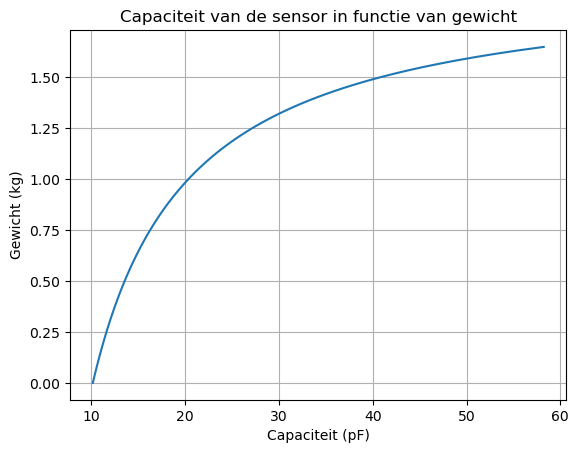

10.160306507808198 58.23250588480313


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit 
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.
def vlakkeplaat_in_functie_van_gewicht(gewicht):
    d_initial = 0.02  # m
    k_cste = 250*4  # N/m
    F= (gewicht+0.040)*9.81
    verandering_d=-F/k_cste
    d = d_initial + verandering_d
    return vlakkeplaat(1.5, 0.1*0.15,d)*1e12  # pF

gewichten = np.linspace(0, 1.65, 100)  # van 0 tot 5 kg
capaciteiten = vlakkeplaat_in_functie_van_gewicht(gewichten)
plt.plot(capaciteiten,gewichten)
plt.ylabel("Gewicht (kg)")
plt.xlabel("Capaciteit (pF)")
plt.title("Capaciteit van de sensor in functie van gewicht")
plt.grid(True)
plt.show()
print(min(capaciteiten),max(capaciteiten))

## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 20 |150 |
| gemiddelde capaciteit| 252 |1200 |
| maximale capaciteit| 525 |2500 |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](Opdracht6_1.jpeg)
![meting 1](Opdracht6_2.jpeg)
![meting 2](Opdracht6_3.jpeg)
![meting 2](Opdracht6_4.jpeg)

## Opdracht 7: Plot de kalibratiegrafiek.

Formule om te fitten op basis van opdracht 4
$$m = \frac{k}{g} (d_{initial} - \frac{\epsilon A}{C})$$

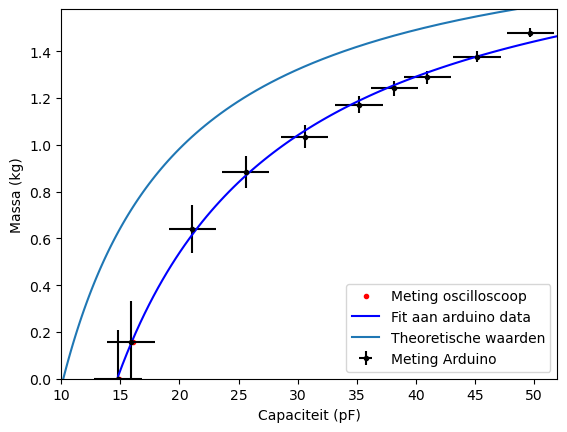

In [4]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.
from scipy.optimize import curve_fit    
massa_meting = np.array([0, 0.155]) #kg, eerste 2 metingen met oscilloscoop
capaciteit_meting = np.array([14.9,16.1]) #pF, met oscilloscoop
massa_meting2 = np.array([0,0.155,0.640,0.885,1.0353,1.1719,1.2423,1.2892,1.3766,1.4801]) #met arduino
capaciteit_meting2 = np.array([14.8,15.9,21.1,25.6,30.6,35.2,38.2,41.0,45.2,49.7]) #pF, met arduino

def kg(capaciteit, a, b):
    return a-(b/capaciteit)#formule uit opdracht 4 om te fitten

pov, cov = curve_fit(kg, capaciteit_meting2, massa_meting2) #fitten van de formule aan de data
a_error, b_error = np.sqrt(np.diag(cov)) #fout op de fit parameters
#doorrekenen van onzekerheid in m 
m_error=np.sqrt( a_error**2 + (b_error**2)/(capaciteit_meting2**2) + (pov[1]**2 * 1.5**2)/(capaciteit_meting2**4) - ((2*cov[0,1])/capaciteit_meting2))


fit_capaciteit = np.linspace(14.8, 52, 100)
fit_massa = kg(fit_capaciteit, pov[0], pov[1])  
plt.figure()
plt.ylabel("Massa (kg)")
plt.xlabel("Capaciteit (pF)")
plt.xlim(10,52)
plt.ylim(0,max(massa_meting2)+0.1)
plt.plot(capaciteit_meting, massa_meting, 'r.', label="Meting oscilloscoop") #metingen oscilloscoop
plt.errorbar(capaciteit_meting2, massa_meting2, xerr=2, yerr=m_error, fmt='k.', label="Meting Arduino") #metingen oscilloscoop met error bars
#plt.plot(capaciteit_meting2, massa_meting2, 'r.', label="Meting arduino") #metingen arduino
plt.plot(fit_capaciteit, fit_massa, 'b-', label="Fit aan arduino data") #fit aan arduino data
plt.plot(capaciteiten, gewichten, label='Theoretische waarden')
plt.legend()
plt.show()


## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* De sensor stabieler maken door meer veren toe te voegen
* De permitiviteit constanter houden, door de uitstekende papieren blaadjes af te plakken. Hierdoor verandert niet de hoeveelheid lucht tussen de platen en is $\epsilon$ consanter.
* De sensor op de grond zetten ipv op de tafel. Hierdoor trilt de sensor minder door externe factoren.
* Waterkan telkens op dezelfde plek zetten, door deze plek af te tekenen op de plaat.

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](Laatste_opstelling.jpeg)
![foto sensor](Laatste_opstelling2.jpeg)

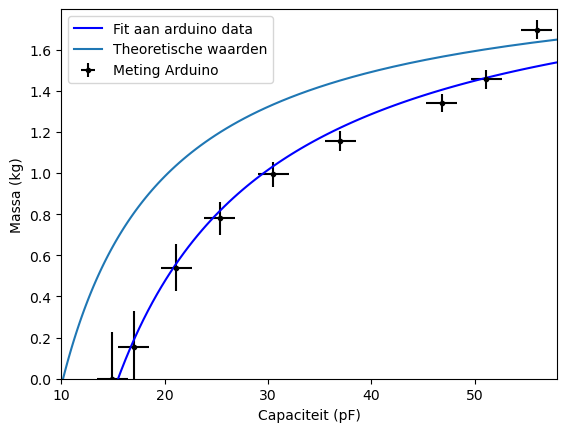

In [5]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij

massa_meting2 = np.array([0,0.155,0.540,0.779,0.993,1.157,1.340,1.4547,1.6964]) #met arduino
capaciteit_meting2 = np.array([14.9,17.0,21.1,25.3,30.5,37.0,46.8, 51.1,56.0]) #pF, met arduino
def kg(capaciteit, a, b):
    return a-(b/capaciteit)#formule uit opdracht 4 om te fitten
pov, cov = curve_fit(kg, capaciteit_meting2, massa_meting2) #fitten van de formule aan de data
a_error, b_error = np.sqrt(np.diag(cov)) #fout op de fit parameters
#doorrekenen van onzekerheid in m 
m_error=np.sqrt( a_error**2 + (b_error**2)/(capaciteit_meting2**2) + (pov[1]**2 * 1.5**2)/(capaciteit_meting2**4) - ((2*cov[0,1])/capaciteit_meting2))

fit_capaciteit = np.linspace(14.9, 58.0, 100)
fit_massa = kg(fit_capaciteit, pov[0], pov[1])  
plt.figure()
plt.ylabel("Massa (kg)")
plt.xlabel("Capaciteit (pF)")
plt.xlim(10,58)
plt.ylim(0,max(massa_meting2)+0.1)
plt.errorbar(capaciteit_meting2, massa_meting2, xerr=1.5, yerr=m_error, fmt='k.', label="Meting Arduino") #metingen oscilloscoop met error bars
plt.plot(fit_capaciteit, fit_massa, 'b-', label="Fit aan arduino data") #fit aan arduino data
plt.plot(capaciteiten, gewichten, label='Theoretische waarden')
plt.legend()
plt.show()

## Opdracht 10: Vul hieronder de conclusie in.

De sensor is een goede sensor op het meetbereik tussen de 0 en 1,5 kg. Wel is de onzekerheid voor massa's in het eerste deel van ons meetbereik te groot om de weegschaal bijvoorbeeld als keukenweegschaal te gebruiken. Na de iteratie was de onzekerheid in de capaciteiten kleiner, omdat de weegschaal stabieler stond en minder trillingen ondervond. Ook was het meetbereik na de iteratie groter. Omdat we niet precies de ${\epsilon}_r$ konden berekenen van onze sensor door de verschillende materialen tussen de platen en we de veerconstante niet exact wisten, is er een verschil tussen de theoretische grafiek op basis van de vlakke plaat formule en de gemeten grafiek. 

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.


In het ontwerpproces hebben we voorspelt hoe de capaciteit verandert als we de grootheid massa willen meten. Op basis van deze voorspelling hebben we een sensor gebouwd. 

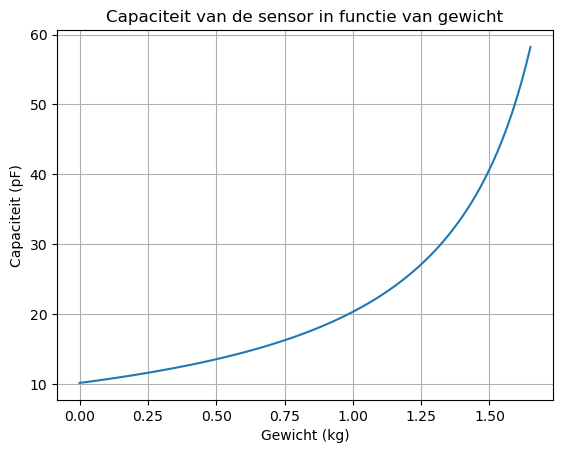

10.160306507808198 58.23250588480313


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit 
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.
def vlakkeplaat_in_functie_van_gewicht(gewicht):
    d_initial = 0.02  # m
    k_cste = 250*4  # N/m
    F= (gewicht+0.040)*9.81
    verandering_d=-F/k_cste
    d = d_initial + verandering_d
    return vlakkeplaat(1.5, 0.1*0.15,d)*1e12  # pF

gewichten = np.linspace(0, 1.65, 100)  
capaciteiten = vlakkeplaat_in_functie_van_gewicht(gewichten)
plt.plot(gewichten, capaciteiten)
plt.xlabel("Gewicht (kg)")
plt.ylabel("Capaciteit (pF)")
plt.title("Capaciteit van de sensor in functie van gewicht")
plt.grid(True)
plt.show()
print(min(capaciteiten),max(capaciteiten))

![foto sensor](Laatste_opstelling.jpeg)

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.
![LTspice meting](LTspic_meting.png)
![meting 1](Opdracht6_1.jpeg)
![meting 1](Opdracht6_2.jpeg)

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.

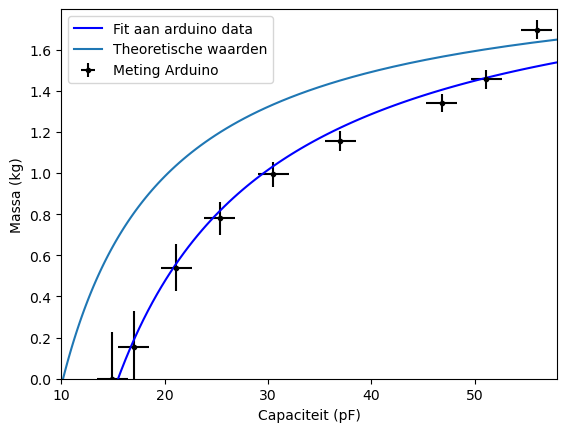

In [7]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij

massa_meting2 = np.array([0,0.155,0.540,0.779,0.993,1.157,1.340,1.4547,1.6964]) #met arduino
capaciteit_meting2 = np.array([14.9,17.0,21.1,25.3,30.5,37.0,46.8, 51.1,56.0]) #pF, met arduino
def kg(capaciteit, a, b):
    return a-(b/capaciteit)#formule uit opdracht 4 om te fitten
pov, cov = curve_fit(kg, capaciteit_meting2, massa_meting2) #fitten van de formule aan de data
a_error, b_error = np.sqrt(np.diag(cov)) #fout op de fit parameters
#doorrekenen van onzekerheid in m 
m_error=np.sqrt( a_error**2 + (b_error**2)/(capaciteit_meting2**2) + (pov[1]**2 * 1.5**2)/(capaciteit_meting2**4) - ((2*cov[0,1])/capaciteit_meting2))

fit_capaciteit = np.linspace(14.9, 58.0, 100)
fit_massa = kg(fit_capaciteit, pov[0], pov[1])  
plt.figure()
plt.ylabel("Massa (kg)")
plt.xlabel("Capaciteit (pF)")
plt.xlim(10,58)
plt.ylim(0,max(massa_meting2)+0.1)
plt.errorbar(capaciteit_meting2, massa_meting2, xerr=1.5, yerr=m_error, fmt='k.', label="Meting Arduino") #metingen oscilloscoop met error bars
plt.plot(fit_capaciteit, fit_massa, 'b-', label="Fit aan arduino data") #fit aan arduino data
plt.plot(capaciteiten, gewichten, label='Theoretische waarden')
plt.legend()
plt.show()

De sensor is een goede sensor op het meetbereik tussen de 0 en 1,5 kg. Wel is de onzekerheid voor massa's in het eerste deel van ons meetbereik te groot om de weegschaal bijvoorbeeld als keukenweegschaal te gebruiken. Na de iteratie was de onzekerheid in de capaciteiten kleiner, omdat de weegschaal stabieler stond en minder trillingen ondervond. Ook was het meetbereik na de iteratie groter. Omdat we niet precies de ${\epsilon}_r$ konden berekenen van onze sensor door de verschillende materialen tussen de platen en we de veerconstante niet exact wisten, is er een verschil tussen de theoretische grafiek op basis van de vlakke plaat formule en de gemeten grafiek. 